# 01 - Data Exploration: OASIS Longitudinal MRI Dataset

This notebook provides a thorough exploratory data analysis of the OASIS longitudinal MRI dataset
for Alzheimer's disease prediction research. We examine 150 subjects across 373 total visits,
with particular attention to the three diagnostic groups (Nondemented, Demented, Converted),
converter trajectories, and the critical MMSE-CDR circularity issue.

**Key goals:**
- Understand the dataset structure, size, and feature types
- Analyze the three-group distribution without collapsing converters
- Investigate converter subjects and their longitudinal trajectories
- Identify the MMSE-CDR circularity that inflates model performance
- Characterize missing data patterns (especially SES)
- Examine feature distributions across groups
- Compute feature correlations to guide modeling decisions

---
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Add project root to path so we can import src modules
sys.path.insert(0, "..")

from src.data_loading import (
    load_longitudinal_raw,
    load_first_visit,
    load_all_visits,
    get_converter_subjects,
    get_converter_trajectories,
)
from src.config import COLOR_PALETTE
from src.visualization import set_style, plot_group_distribution

# Apply publication-quality style
set_style()

print("Setup complete.")
print(f"Color palette: {COLOR_PALETTE}")

Setup complete.
Color palette: {'Nondemented': '#2ecc71', 'Demented': '#e74c3c', 'Converted': '#f39c12'}


---
## 2. Raw Data Overview

The OASIS longitudinal dataset contains MRI data from 150 subjects aged 60-96, each scanned
on two or more visits separated by at least one year. The dataset includes demographic,
clinical, and neuroimaging measures.

In [2]:
# Load the raw longitudinal data (no imputation, no encoding)
df_raw = load_longitudinal_raw()

print(f"Dataset shape: {df_raw.shape}")
print(f"Number of unique subjects: {df_raw['Subject ID'].nunique()}")
print(f"Total visits: {len(df_raw)}")
print(f"\nVisits per subject:")
print(df_raw.groupby("Subject ID")["Visit"].max().value_counts().sort_index().to_string())

Dataset shape: (373, 15)
Number of unique subjects: 150
Total visits: 373

Visits per subject:
Visit
2    92
3    43
4     9
5     6


In [3]:
# Column names and data types
print("Columns and dtypes:")
print("=" * 40)
for col in df_raw.columns:
    print(f"  {col:<15} {str(df_raw[col].dtype):<10} ({df_raw[col].notna().sum()} non-null)")

Columns and dtypes:
  Subject ID      object     (373 non-null)
  MRI ID          object     (373 non-null)
  Group           object     (373 non-null)
  Visit           int64      (373 non-null)
  MR Delay        int64      (373 non-null)
  M/F             object     (373 non-null)
  Hand            object     (373 non-null)
  Age             int64      (373 non-null)
  EDUC            int64      (373 non-null)
  SES             float64    (354 non-null)
  MMSE            float64    (371 non-null)
  CDR             float64    (373 non-null)
  eTIV            int64      (373 non-null)
  nWBV            float64    (373 non-null)
  ASF             float64    (373 non-null)


In [4]:
# First few rows
df_raw.head(10)

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034
5,OAS2_0004,OAS2_0004_MR1,Nondemented,1,0,F,R,88,18,3.0,28.0,0.0,1215,0.710,1.444
6,OAS2_0004,OAS2_0004_MR2,Nondemented,2,538,F,R,90,18,3.0,27.0,0.0,1200,0.718,1.462
7,OAS2_0005,OAS2_0005_MR1,Nondemented,1,0,M,R,80,12,4.0,28.0,0.0,1689,0.712,1.039
8,OAS2_0005,OAS2_0005_MR2,Nondemented,2,1010,M,R,83,12,4.0,29.0,0.5,1701,0.711,1.032
9,OAS2_0005,OAS2_0005_MR3,Nondemented,3,1603,M,R,85,12,4.0,30.0,0.0,1699,0.705,1.033


In [5]:
# Descriptive statistics for numeric columns
df_raw.describe().round(3)

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000,373.000,373.000,373.000,354.000,371.000,373.000,373.000,373.000,373.000
mean,1.882,595.105,77.013,14.598,2.460,27.342,0.291,1488.129,0.730,1.195
std,0.923,635.485,7.641,2.876,1.134,3.683,0.375,176.139,0.037,0.138
min,1.000,0.000,60.000,6.000,1.000,4.000,0.000,1106.000,0.644,0.876
25%,1.000,0.000,71.000,12.000,2.000,27.000,0.000,1357.000,0.700,1.099
50%,2.000,552.000,77.000,15.000,2.000,29.000,0.000,1470.000,0.729,1.194
75%,2.000,873.000,82.000,16.000,3.000,30.000,0.500,1597.000,0.756,1.293
max,5.000,2639.000,98.000,23.000,5.000,30.000,2.000,2004.000,0.837,1.587


**Key observations:**
- 150 unique subjects with 373 total visits (average ~2.5 visits per subject)
- Age ranges from 60 to 98
- MMSE ranges from 4 to 30 (30 = perfect score)
- CDR ranges from 0 (no dementia) to 2 (moderate dementia)
- nWBV (normalized whole brain volume) ranges from ~0.64 to ~0.84
- SES has missing values (note the count difference)

---
## 3. Three-Group Analysis

The OASIS dataset labels each subject into one of three groups:
- **Nondemented**: CDR = 0 across all visits
- **Demented**: CDR > 0 from the first visit onward
- **Converted**: CDR = 0 at baseline, then CDR > 0 at a later visit

We deliberately keep all three groups separate rather than collapsing Converted into Demented.
This is important because converters represent a clinically distinct trajectory.

In [6]:
# Load first-visit data (one row per subject, 150 total)
df_first = load_first_visit(impute_strategy="median")

print(f"First-visit dataset: {df_first.shape}")
print(f"\nGroup counts (first visit):")
group_counts = df_first["Group"].value_counts()
for group, count in group_counts.items():
    pct = count / len(df_first) * 100
    print(f"  {group:<15} {count:>3} subjects ({pct:.1f}%)")

First-visit dataset: (150, 18)

Group counts (first visit):
  Nondemented      72 subjects (48.0%)
  Demented         64 subjects (42.7%)
  Converted        14 subjects (9.3%)


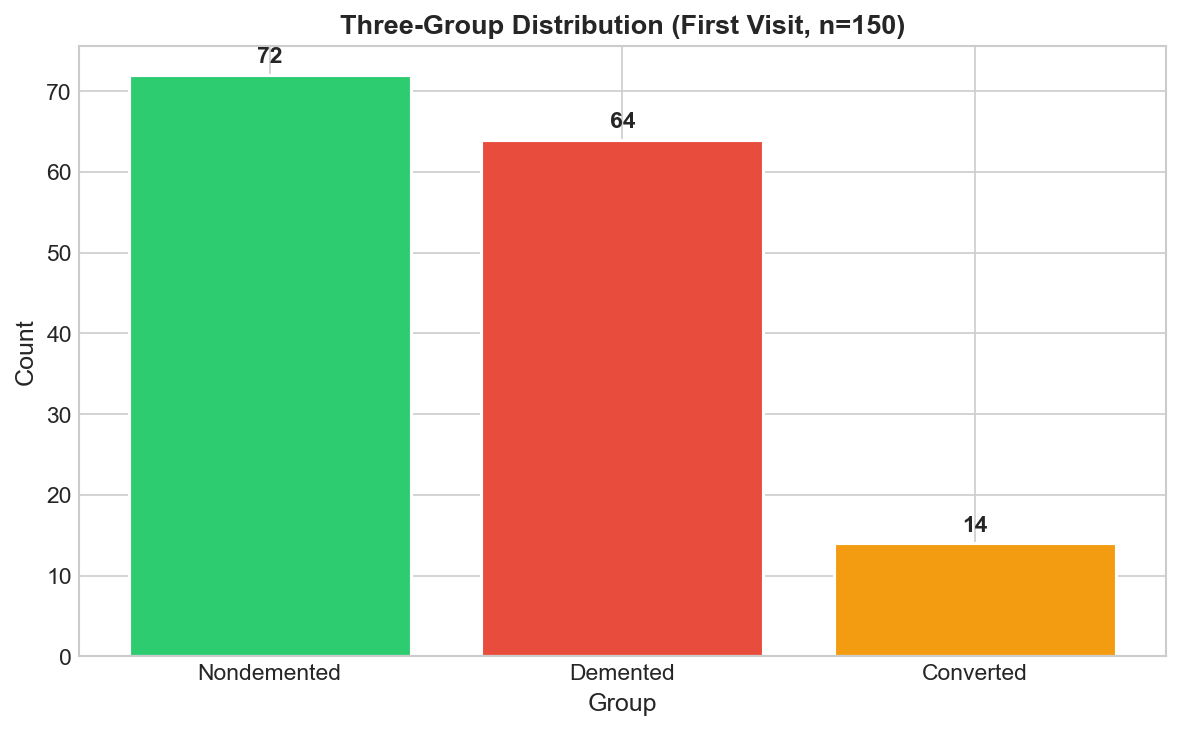

In [7]:
# Group distribution bar chart
fig = plot_group_distribution(df_first, title="Three-Group Distribution (First Visit, n=150)")
plt.tight_layout()
plt.show()

In [8]:
# Descriptive statistics per group
numeric_cols = ["Age", "EDUC", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]
group_stats = df_first.groupby("Group")[numeric_cols].describe().round(3)

# Show mean and std for each group side-by-side
summary = df_first.groupby("Group")[numeric_cols].agg(["mean", "std", "min", "max"]).round(3)
summary

Age                   EDUC                   SES         ...  \
               mean    std min max    mean    std min max   mean    std  ...   
Group                                                                    ...   
Converted    77.071  7.691  65  87  15.143  2.568  12  20  1.857  1.027  ...   
Demented     75.109  6.736  61  96  13.688  2.916   6  20  2.656  1.130  ...   
Nondemented  75.431  8.232  60  93  15.167  2.732   8  23  2.417  1.058  ...   

             eTIV         nWBV                         ASF                \
              min   max   mean    std    min    max   mean    std    min   
Group                                                                      
Converted    1264  1704  0.738  0.033  0.693  0.799  1.229  0.109  1.030   
Demented     1151  1957  0.724  0.031  0.660  0.806  1.205  0.137  0.897   
Nondemented  1123  1987  0.746  0.039  0.666  0.837  1.203  0.145  0.883   

                    
               max  
Group               
Converted    1.388  
Demented     1.525  
Nondemented  1.563  

[3 rows x 32 columns]

In [9]:
# Gender distribution by group
gender_by_group = pd.crosstab(df_first["Group"], df_first["M/F"], margins=True)
print("Gender distribution by group:")
print(gender_by_group)
print("\nGender proportions by group:")
print(pd.crosstab(df_first["Group"], df_first["M/F"], normalize="index").round(3))

Gender distribution by group:
M/F           F   M  All
Group                   
Converted    10   4   14
Demented     28  36   64
Nondemented  50  22   72
All          88  62  150

Gender proportions by group:
M/F              F      M
Group                    
Converted    0.714  0.286
Demented     0.438  0.562
Nondemented  0.694  0.306


---
## 4. Converter Deep-Dive

Converters are the most clinically interesting group: subjects who were cognitively normal at
baseline but progressed to dementia during the study. Understanding their trajectories is
essential for early detection research.

In [10]:
# Identify converter subjects
converter_ids = get_converter_subjects()
print(f"Number of converter subjects: {len(converter_ids)}")
print(f"Subject IDs: {converter_ids}")

Number of converter subjects: 14
Subject IDs: ['OAS2_0018', 'OAS2_0020', 'OAS2_0031', 'OAS2_0041', 'OAS2_0054', 'OAS2_0092', 'OAS2_0103', 'OAS2_0118', 'OAS2_0127', 'OAS2_0131', 'OAS2_0133', 'OAS2_0144', 'OAS2_0145', 'OAS2_0176']


In [11]:
# Get all visits for converter subjects
df_converters = get_converter_trajectories()

print(f"Total converter visits: {len(df_converters)}")
print(f"\nConverter trajectory table:")
display_cols = ["Subject ID", "Visit", "MR Delay", "Age", "MMSE", "CDR", "nWBV", "eTIV"]
df_converters[display_cols]

Total converter visits: 37

Converter trajectory table:


,Subject ID,Visit,MR Delay,Age,MMSE,CDR,nWBV,eTIV
33,OAS2_0018,1,0,87,30.0,0.0,0.715,1406
34,OAS2_0018,3,489,88,29.0,0.0,0.713,1398
35,OAS2_0018,4,1933,92,27.0,0.5,0.696,1423
36,OAS2_0020,1,0,80,29.0,0.0,0.693,1587
37,OAS2_0020,2,756,82,28.0,0.5,0.677,1606
38,OAS2_0020,3,1563,84,26.0,0.5,0.666,1597
57,OAS2_0031,1,0,86,30.0,0.0,0.718,1430
58,OAS2_0031,2,446,88,30.0,0.0,0.719,1445
59,OAS2_0031,3,1588,91,28.0,0.5,0.696,1463
81,OAS2_0041,1,0,71,27.0,0.0,0.771,1289


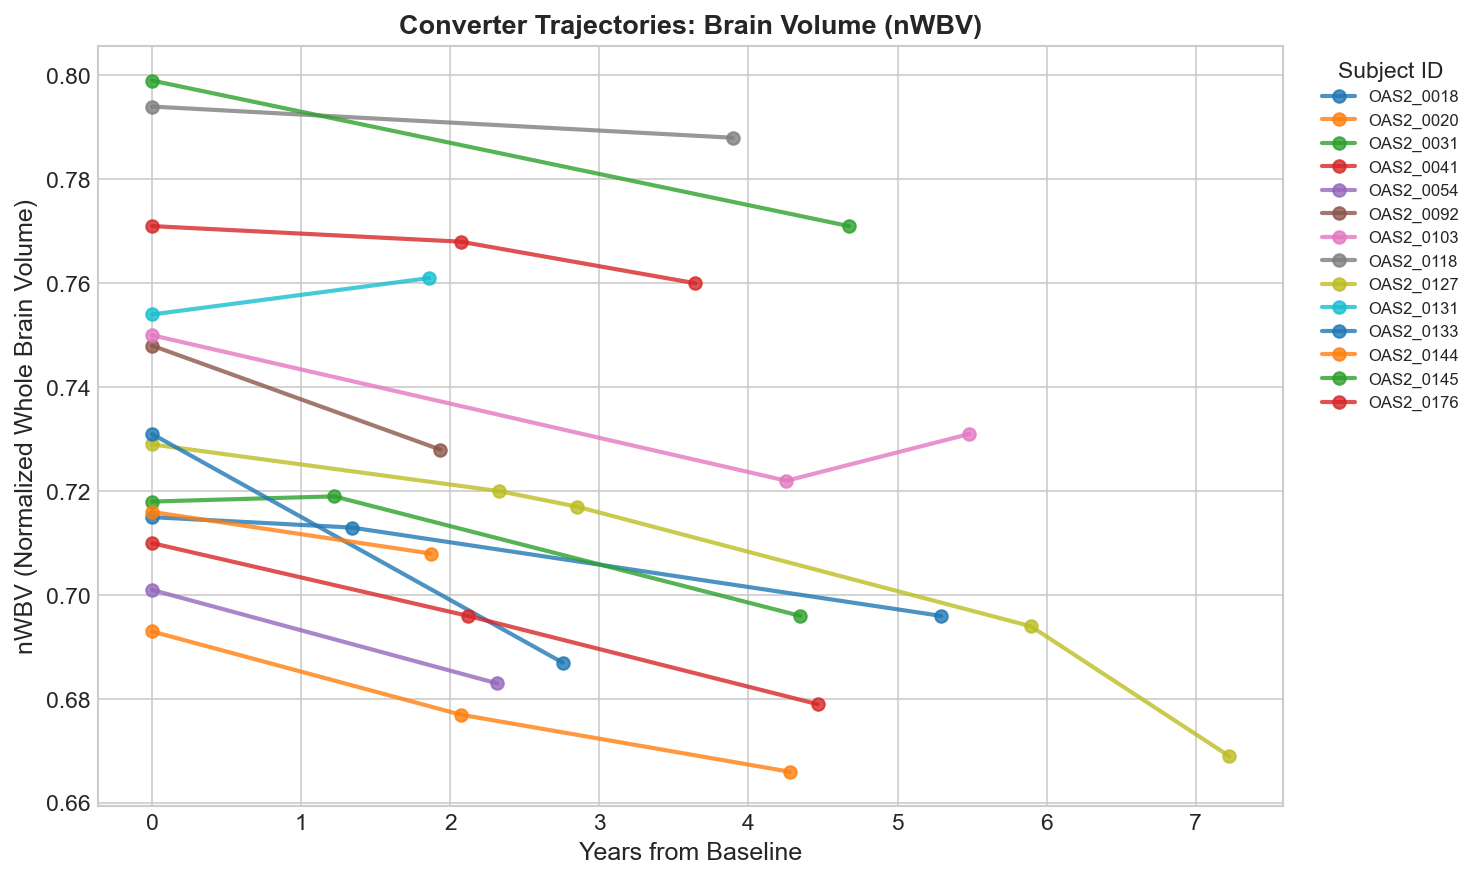

In [12]:
# Spaghetti plot: nWBV trajectories for converters
fig, ax = plt.subplots(figsize=(10, 6))

for subject_id, group in df_converters.groupby("Subject ID"):
    group = group.sort_values("Visit")
    years_from_baseline = group["MR Delay"] / 365.25
    ax.plot(
        years_from_baseline,
        group["nWBV"],
        marker="o",
        label=subject_id,
        alpha=0.8,
        linewidth=2,
    )

ax.set_xlabel("Years from Baseline", fontsize=12)
ax.set_ylabel("nWBV (Normalized Whole Brain Volume)", fontsize=12)
ax.set_title("Converter Trajectories: Brain Volume (nWBV)", fontweight="bold", fontsize=13)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Subject ID")
plt.tight_layout()
plt.show()

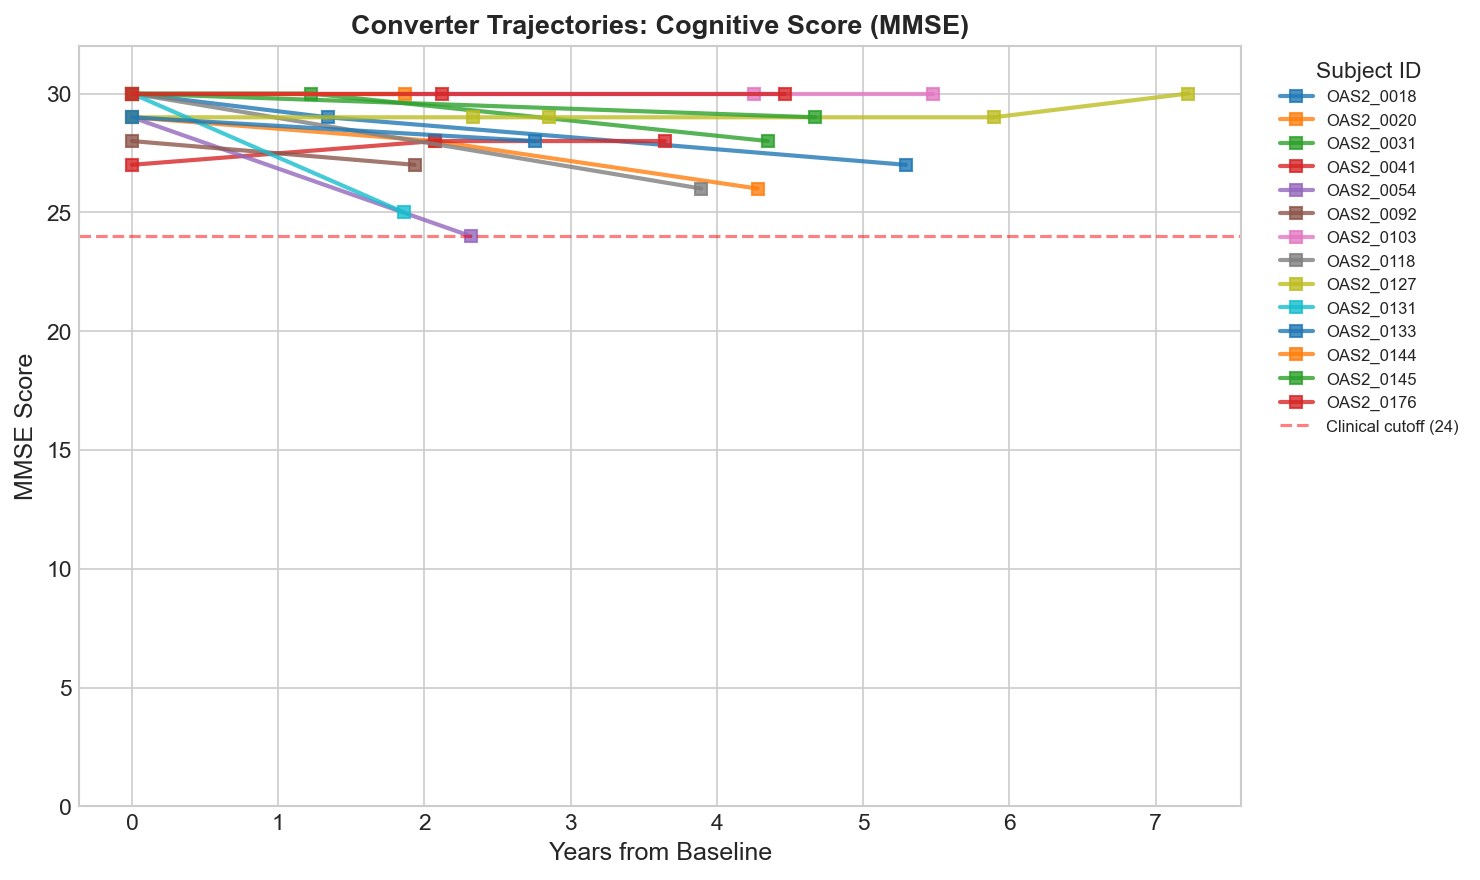

In [13]:
# Spaghetti plot: MMSE trajectories for converters
fig, ax = plt.subplots(figsize=(10, 6))

for subject_id, group in df_converters.groupby("Subject ID"):
    group = group.sort_values("Visit")
    years_from_baseline = group["MR Delay"] / 365.25
    ax.plot(
        years_from_baseline,
        group["MMSE"],
        marker="s",
        label=subject_id,
        alpha=0.8,
        linewidth=2,
    )

ax.set_xlabel("Years from Baseline", fontsize=12)
ax.set_ylabel("MMSE Score", fontsize=12)
ax.set_title("Converter Trajectories: Cognitive Score (MMSE)", fontweight="bold", fontsize=13)
ax.axhline(y=24, color="red", linestyle="--", alpha=0.5, label="Clinical cutoff (24)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Subject ID")
ax.set_ylim(0, 32)
plt.tight_layout()
plt.show()

In [14]:
# Descriptive statistics: converters vs stable groups
compare_cols = ["Age", "EDUC", "SES", "MMSE", "CDR", "nWBV", "eTIV"]

print("Converter vs Stable Group Comparison (First Visit)")
print("=" * 60)
comparison = df_first.groupby("Group")[compare_cols].agg(["mean", "std"]).round(3)
comparison

Converter vs Stable Group Comparison (First Visit)


Age           EDUC           SES           MMSE           CDR  \
               mean    std    mean    std   mean    std    mean    std   mean   
Group                                                                           
Converted    77.071  7.691  15.143  2.568  1.857  1.027  29.357  0.929  0.036   
Demented     75.109  6.736  13.688  2.916  2.656  1.130  25.328  3.319  0.602   
Nondemented  75.431  8.232  15.167  2.732  2.417  1.058  29.194  0.850  0.000   

                     nWBV             eTIV           
               std   mean    std      mean      std  
Group                                                
Converted    0.134  0.738  0.033  1438.286  132.945  
Demented     0.203  0.724  0.031  1475.938  173.615  
Nondemented  0.000  0.746  0.039  1480.111  183.747

**Converter observations:**
- Converters show declining nWBV (brain atrophy) across visits
- MMSE scores tend to decrease as subjects convert to dementia
- At first visit, converters often appear similar to the Nondemented group
  (since they have not yet converted), making early detection challenging
- The small sample size (n~8) limits statistical power for converter-specific analyses

---
## 5. CDR-MMSE Circularity Analysis

**This is the single most important methodological insight in this project.**

The Clinical Dementia Rating (CDR) is used to *define* the diagnosis label (Group column):
- CDR = 0 at all visits --> Nondemented
- CDR > 0 from first visit --> Demented
- CDR transitions from 0 to >0 --> Converted

The Mini-Mental State Examination (MMSE) is a cognitive screening test that is **highly correlated
with CDR**. Using MMSE as a predictive feature while CDR defines the target creates **circularity**:
the model essentially learns to predict a label from a near-proxy of that same label.

This is why many published analyses report >90% accuracy on OASIS data -- they are not predicting
dementia from MRI or demographics, they are predicting CDR from MMSE.

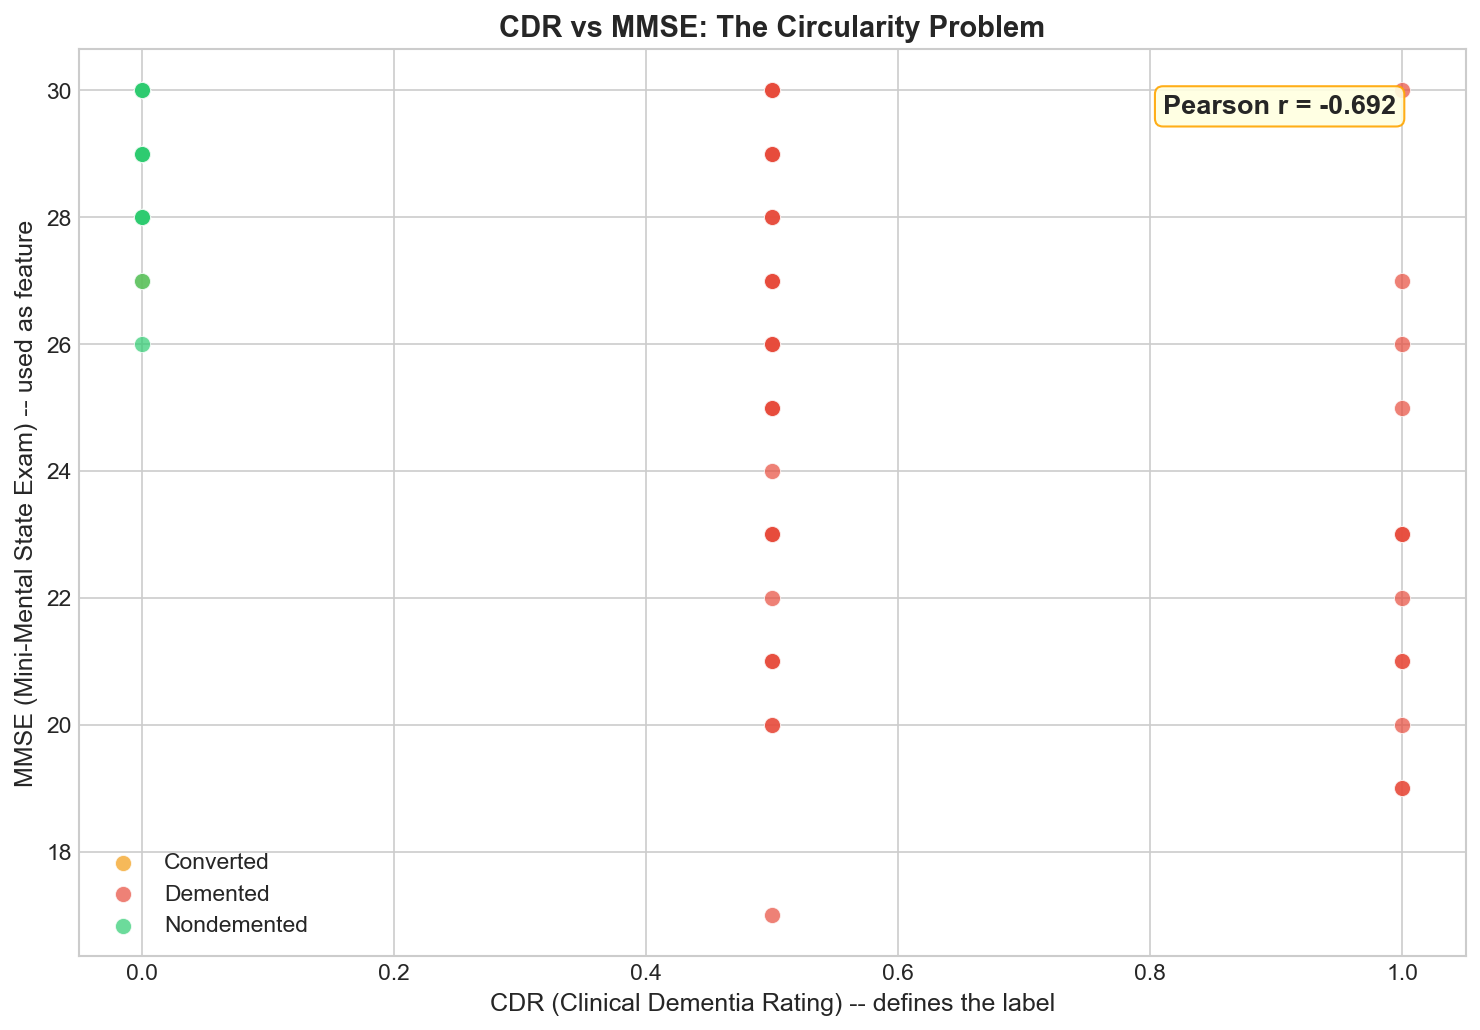


Pearson correlation between CDR and MMSE: -0.6919
This strong negative correlation means MMSE is nearly a proxy for CDR.
Using MMSE as a feature to predict a CDR-derived label is circular.


In [15]:
# CDR vs MMSE scatter plot colored by group
fig, ax = plt.subplots(figsize=(10, 7))

for group_name, group_data in df_first.groupby("Group"):
    color = COLOR_PALETTE.get(group_name, "#95a5a6")
    ax.scatter(
        group_data["CDR"],
        group_data["MMSE"],
        c=color,
        label=group_name,
        alpha=0.7,
        s=60,
        edgecolors="white",
        linewidth=0.5,
    )

# Calculate and display correlation
corr = df_first["CDR"].corr(df_first["MMSE"])
ax.text(
    0.95, 0.95,
    f"Pearson r = {corr:.3f}",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=13,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="orange", alpha=0.9),
)

ax.set_xlabel("CDR (Clinical Dementia Rating) -- defines the label", fontsize=12)
ax.set_ylabel("MMSE (Mini-Mental State Exam) -- used as feature", fontsize=12)
ax.set_title("CDR vs MMSE: The Circularity Problem", fontweight="bold", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nPearson correlation between CDR and MMSE: {corr:.4f}")
print(f"This strong negative correlation means MMSE is nearly a proxy for CDR.")
print(f"Using MMSE as a feature to predict a CDR-derived label is circular.")

/var/folders/jd/_f8_k_8s5178lr2fl45k25k80000gn/T/ipykernel_68858/3837840040.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


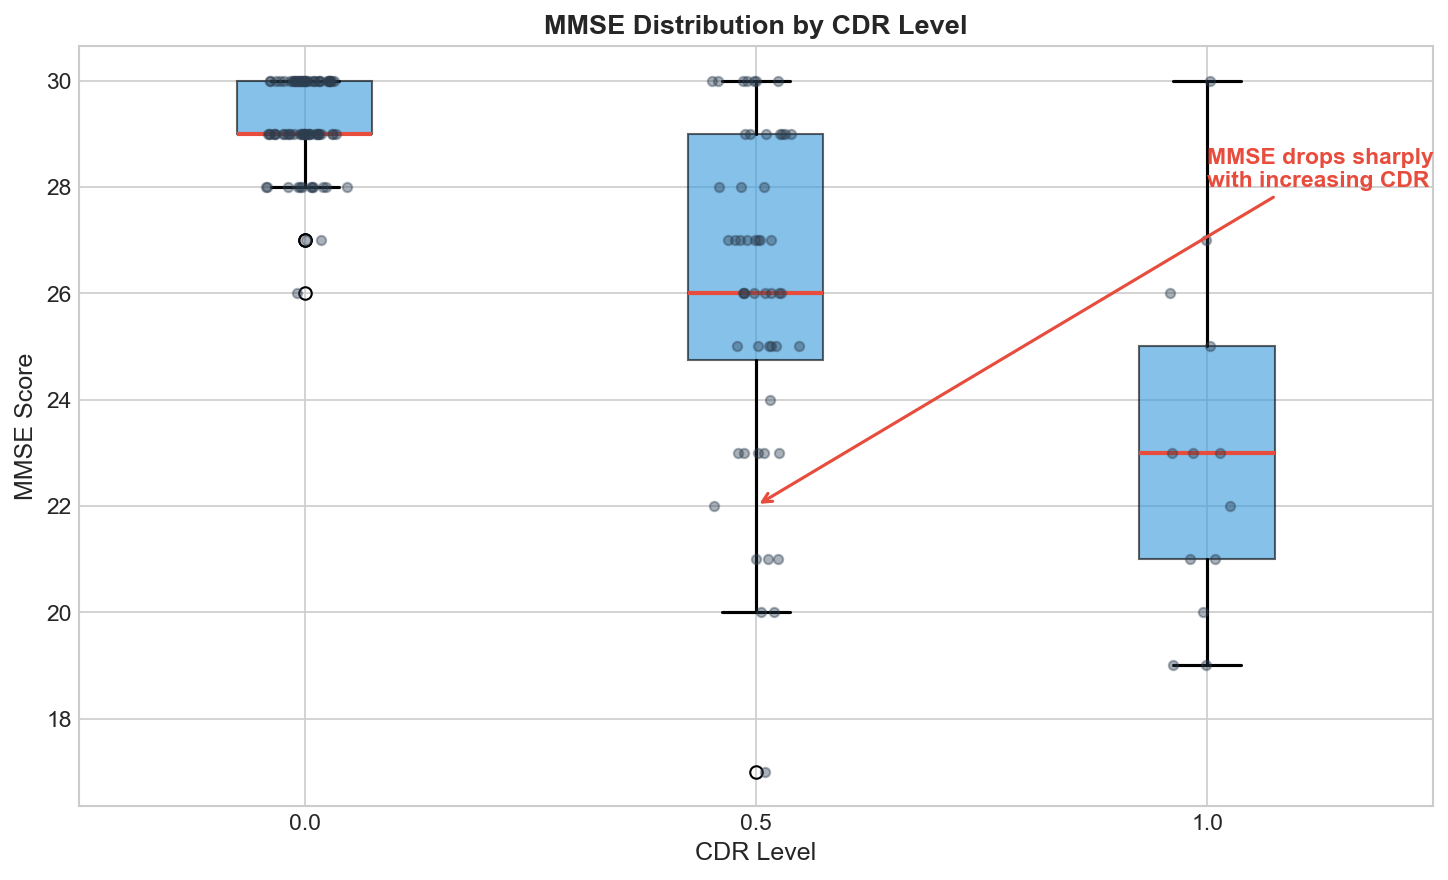


MMSE statistics by CDR level:
     count   mean   std   min    25%   50%   75%   max
CDR                                                   
0.0   85.0  29.21  0.86  26.0  29.00  29.0  30.0  30.0
0.5   52.0  26.00  3.11  17.0  24.75  26.0  29.0  30.0
1.0   13.0  23.00  3.27  19.0  21.00  23.0  25.0  30.0


In [16]:
# Boxplot of MMSE by CDR level
fig, ax = plt.subplots(figsize=(10, 6))

cdr_levels = sorted(df_first["CDR"].dropna().unique())
mmse_by_cdr = [df_first[df_first["CDR"] == level]["MMSE"].dropna().values for level in cdr_levels]

bp = ax.boxplot(
    mmse_by_cdr,
    labels=[str(c) for c in cdr_levels],
    patch_artist=True,
    boxprops=dict(facecolor="#3498db", alpha=0.6),
    medianprops=dict(color="#e74c3c", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)

# Add individual points
for i, (level, data) in enumerate(zip(cdr_levels, mmse_by_cdr)):
    x = np.random.normal(i + 1, 0.04, size=len(data))
    ax.scatter(x, data, alpha=0.4, color="#2c3e50", s=20, zorder=3)

ax.set_xlabel("CDR Level", fontsize=12)
ax.set_ylabel("MMSE Score", fontsize=12)
ax.set_title("MMSE Distribution by CDR Level", fontweight="bold", fontsize=13)

# Add annotation
ax.annotate(
    "MMSE drops sharply\nwith increasing CDR",
    xy=(2, 22), xytext=(3, 28),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", color="#e74c3c", lw=1.5),
    color="#e74c3c",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

print("\nMMSE statistics by CDR level:")
print(df_first.groupby("CDR")["MMSE"].describe().round(2))

**Circularity conclusion:**

CDR and MMSE are strongly negatively correlated. Since CDR directly determines the Group label,
including MMSE as a feature allows models to "cheat" -- they learn MMSE --> CDR --> Group,
rather than learning genuine neuroimaging or demographic predictors of dementia.

**Implication for modeling:** We must run an ablation study comparing models WITH and WITHOUT MMSE
to quantify the performance inflation. The honest evaluation uses the feature set *without* MMSE.

---
## 6. Missing Data Patterns

Understanding missingness is critical for a dataset with only 150 subjects.
Every dropped row is a significant loss of statistical power.

In [17]:
# Missing value summary
df_raw_first = df_raw[df_raw["Visit"] == 1].copy()

print("Missing values in first-visit data (n=150):")
print("=" * 45)
missing = df_raw_first.isnull().sum()
for col, count in missing.items():
    if count > 0:
        pct = count / len(df_raw_first) * 100
        print(f"  {col:<15} {count:>3} missing ({pct:.1f}%)")

if missing.sum() == 0:
    # Check all visits too
    pass

print(f"\nTotal missing cells: {df_raw_first.isnull().sum().sum()}")
print(f"Columns with no missing: {(missing == 0).sum()} / {len(missing)}")

Missing values in first-visit data (n=150):
  SES               8 missing (5.3%)

Total missing cells: 8
Columns with no missing: 14 / 15


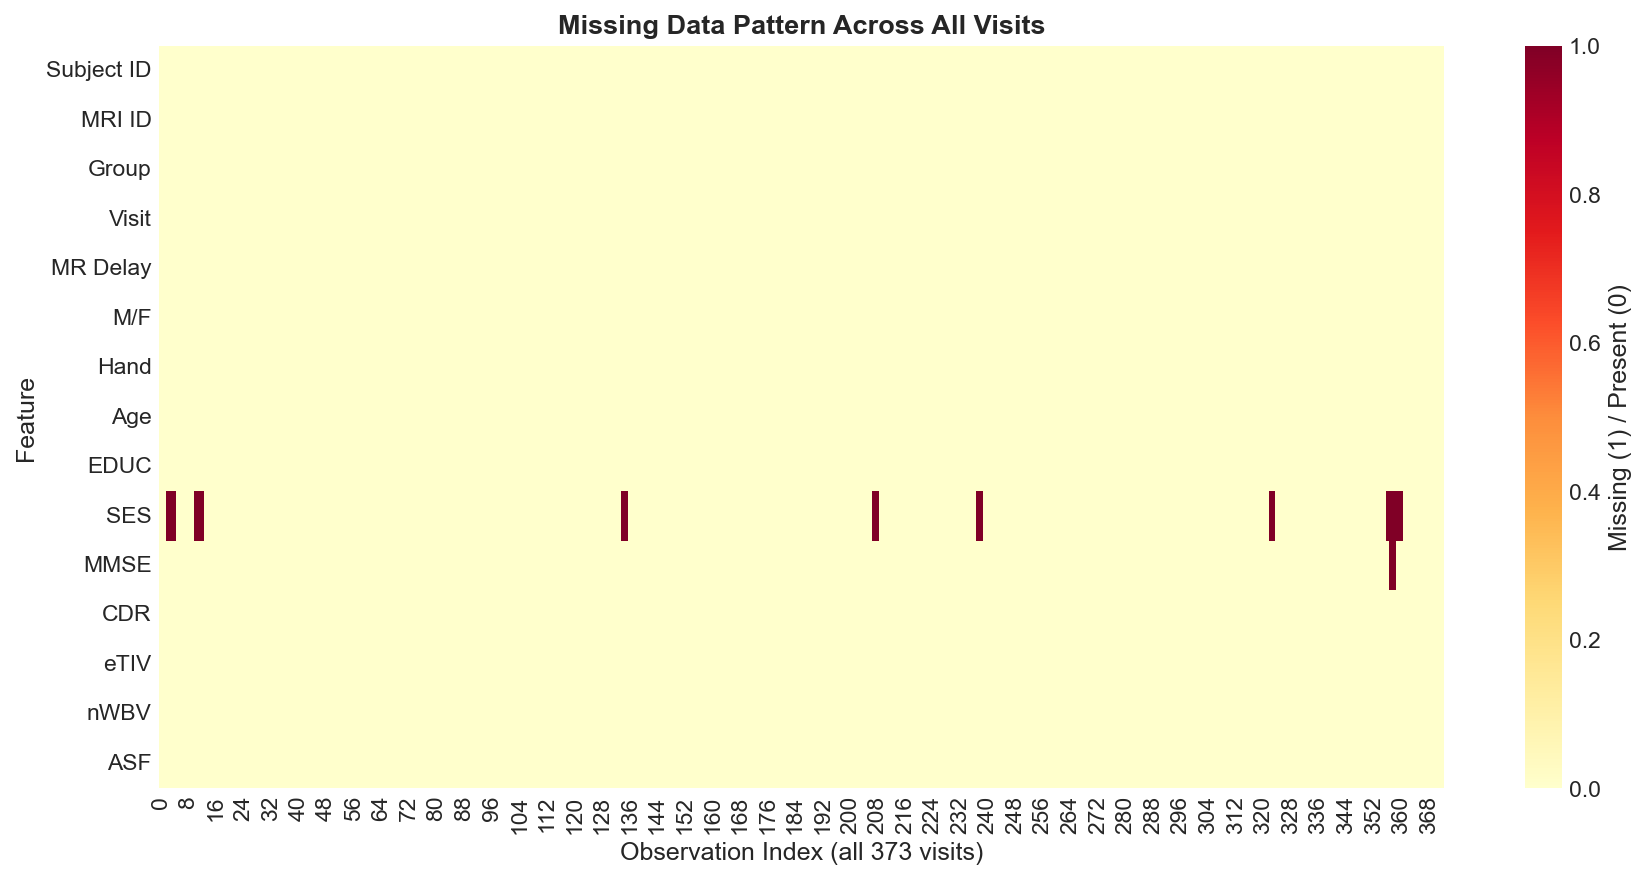

In [18]:
# Missing data heatmap (all visits)
fig, ax = plt.subplots(figsize=(12, 6))

# Use raw data to see true missingness
missing_matrix = df_raw.isnull().astype(int)

sns.heatmap(
    missing_matrix.T,
    cbar_kws={"label": "Missing (1) / Present (0)"},
    yticklabels=df_raw.columns,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0,
)

ax.set_xlabel("Observation Index (all 373 visits)", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.set_title("Missing Data Pattern Across All Visits", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Focus on SES missingness
print("SES Missingness Analysis")
print("=" * 45)

# How many unique subjects have missing SES?
ses_missing_mask = df_raw["SES"].isnull()
subjects_missing_ses = df_raw[ses_missing_mask]["Subject ID"].unique()
print(f"Subjects with missing SES: {len(subjects_missing_ses)}")
print(f"Subject IDs: {list(subjects_missing_ses)}")

# Is missingness related to group?
print(f"\nSES missingness by Group (first visit):")
df_raw_first["SES_missing"] = df_raw_first["SES"].isnull().astype(int)
ses_miss_by_group = df_raw_first.groupby("Group")["SES_missing"].agg(["sum", "count"])
ses_miss_by_group["pct_missing"] = (ses_miss_by_group["sum"] / ses_miss_by_group["count"] * 100).round(1)
ses_miss_by_group.columns = ["N Missing", "N Total", "% Missing"]
print(ses_miss_by_group)

SES Missingness Analysis
Subjects with missing SES: 8
Subject IDs: ['OAS2_0002', 'OAS2_0007', 'OAS2_0063', 'OAS2_0099', 'OAS2_0114', 'OAS2_0160', 'OAS2_0181', 'OAS2_0182']

SES missingness by Group (first visit):
             N Missing  N Total  % Missing
Group                                     
Converted            0       14        0.0
Demented             8       64       12.5
Nondemented          0       72        0.0


**Missing data conclusions:**
- SES is the only feature with meaningful missingness (~8 subjects)
- MMSE has very few missing values (if any)
- Given the small dataset (n=150), we impute SES (median) rather than dropping rows
- The missingness pattern does not appear strongly related to diagnostic group,
  suggesting it may be Missing at Random (MAR)

---
## 7. Feature Distributions

We examine the distribution of each feature across the three diagnostic groups using
kernel density estimation (KDE) plots and box plots.

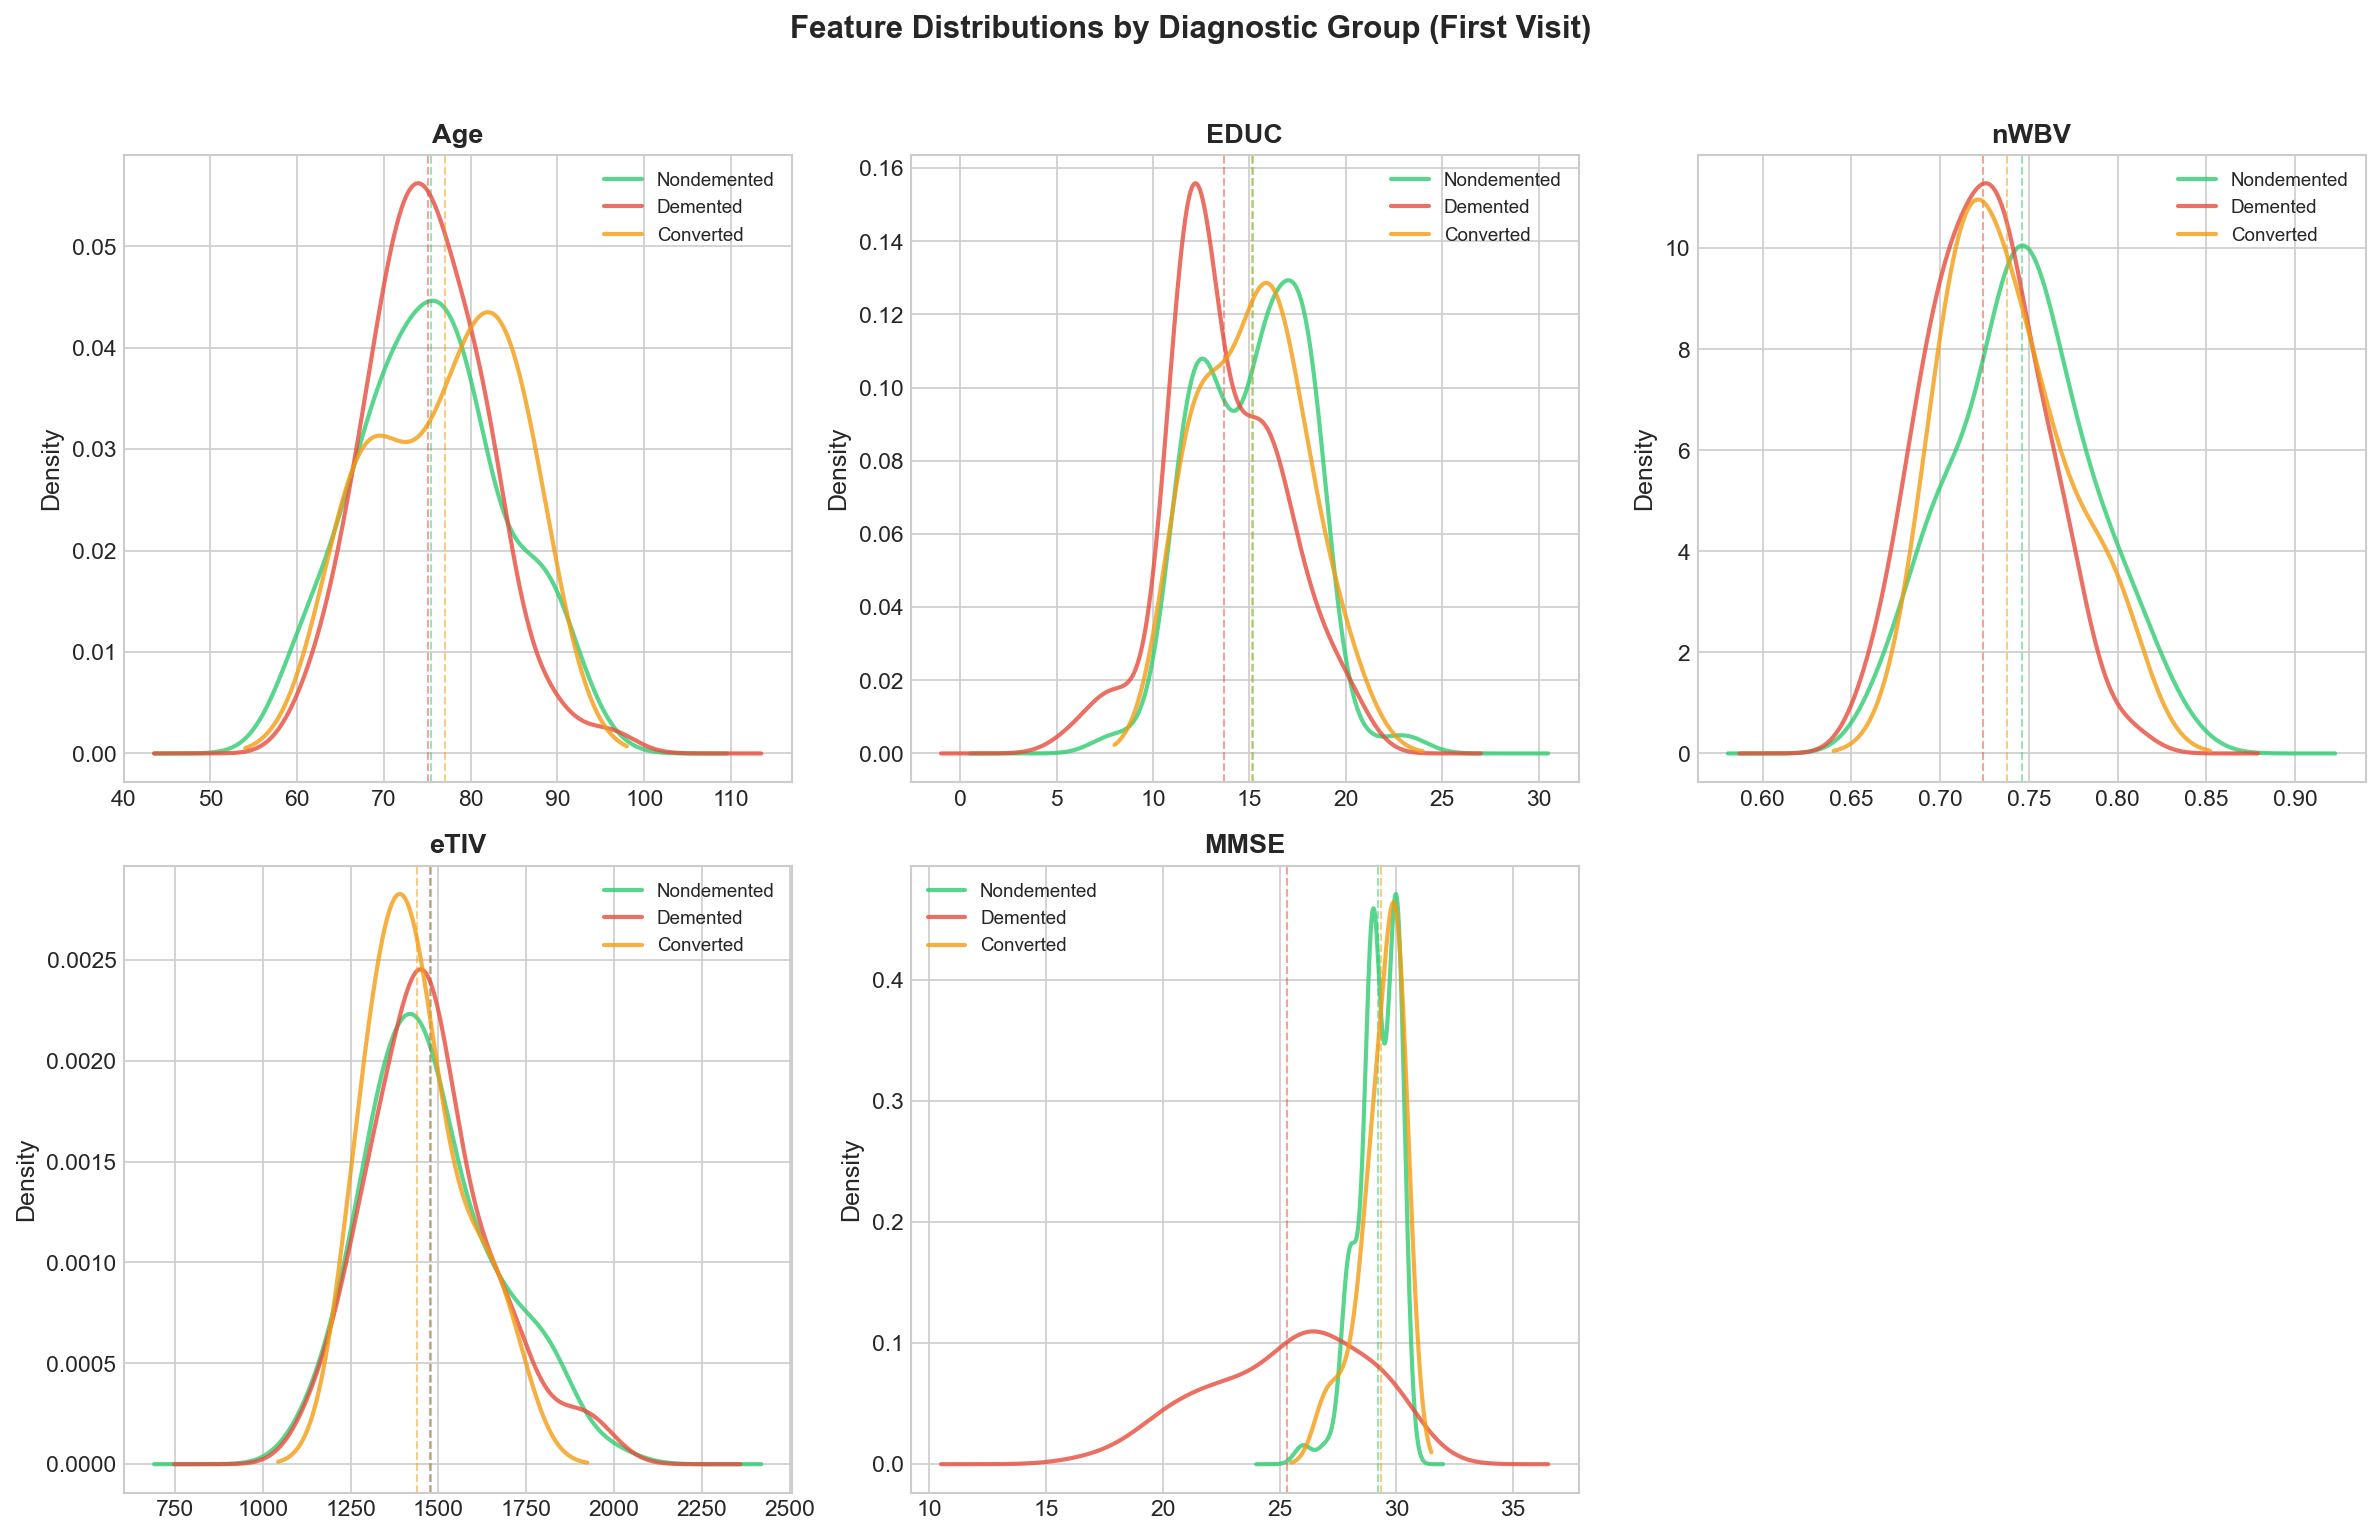

In [20]:
# KDE plots of key features by group
kde_features = ["Age", "EDUC", "nWBV", "eTIV", "MMSE"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(kde_features):
    ax = axes[i]
    for group_name in ["Nondemented", "Demented", "Converted"]:
        data = df_first[df_first["Group"] == group_name][feature].dropna()
        if len(data) > 1:
            color = COLOR_PALETTE[group_name]
            data.plot.kde(ax=ax, label=group_name, color=color, linewidth=2, alpha=0.8)
            ax.axvline(data.mean(), color=color, linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(feature, fontweight="bold", fontsize=13)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

# Hide the unused subplot
axes[-1].set_visible(False)

fig.suptitle("Feature Distributions by Diagnostic Group (First Visit)", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

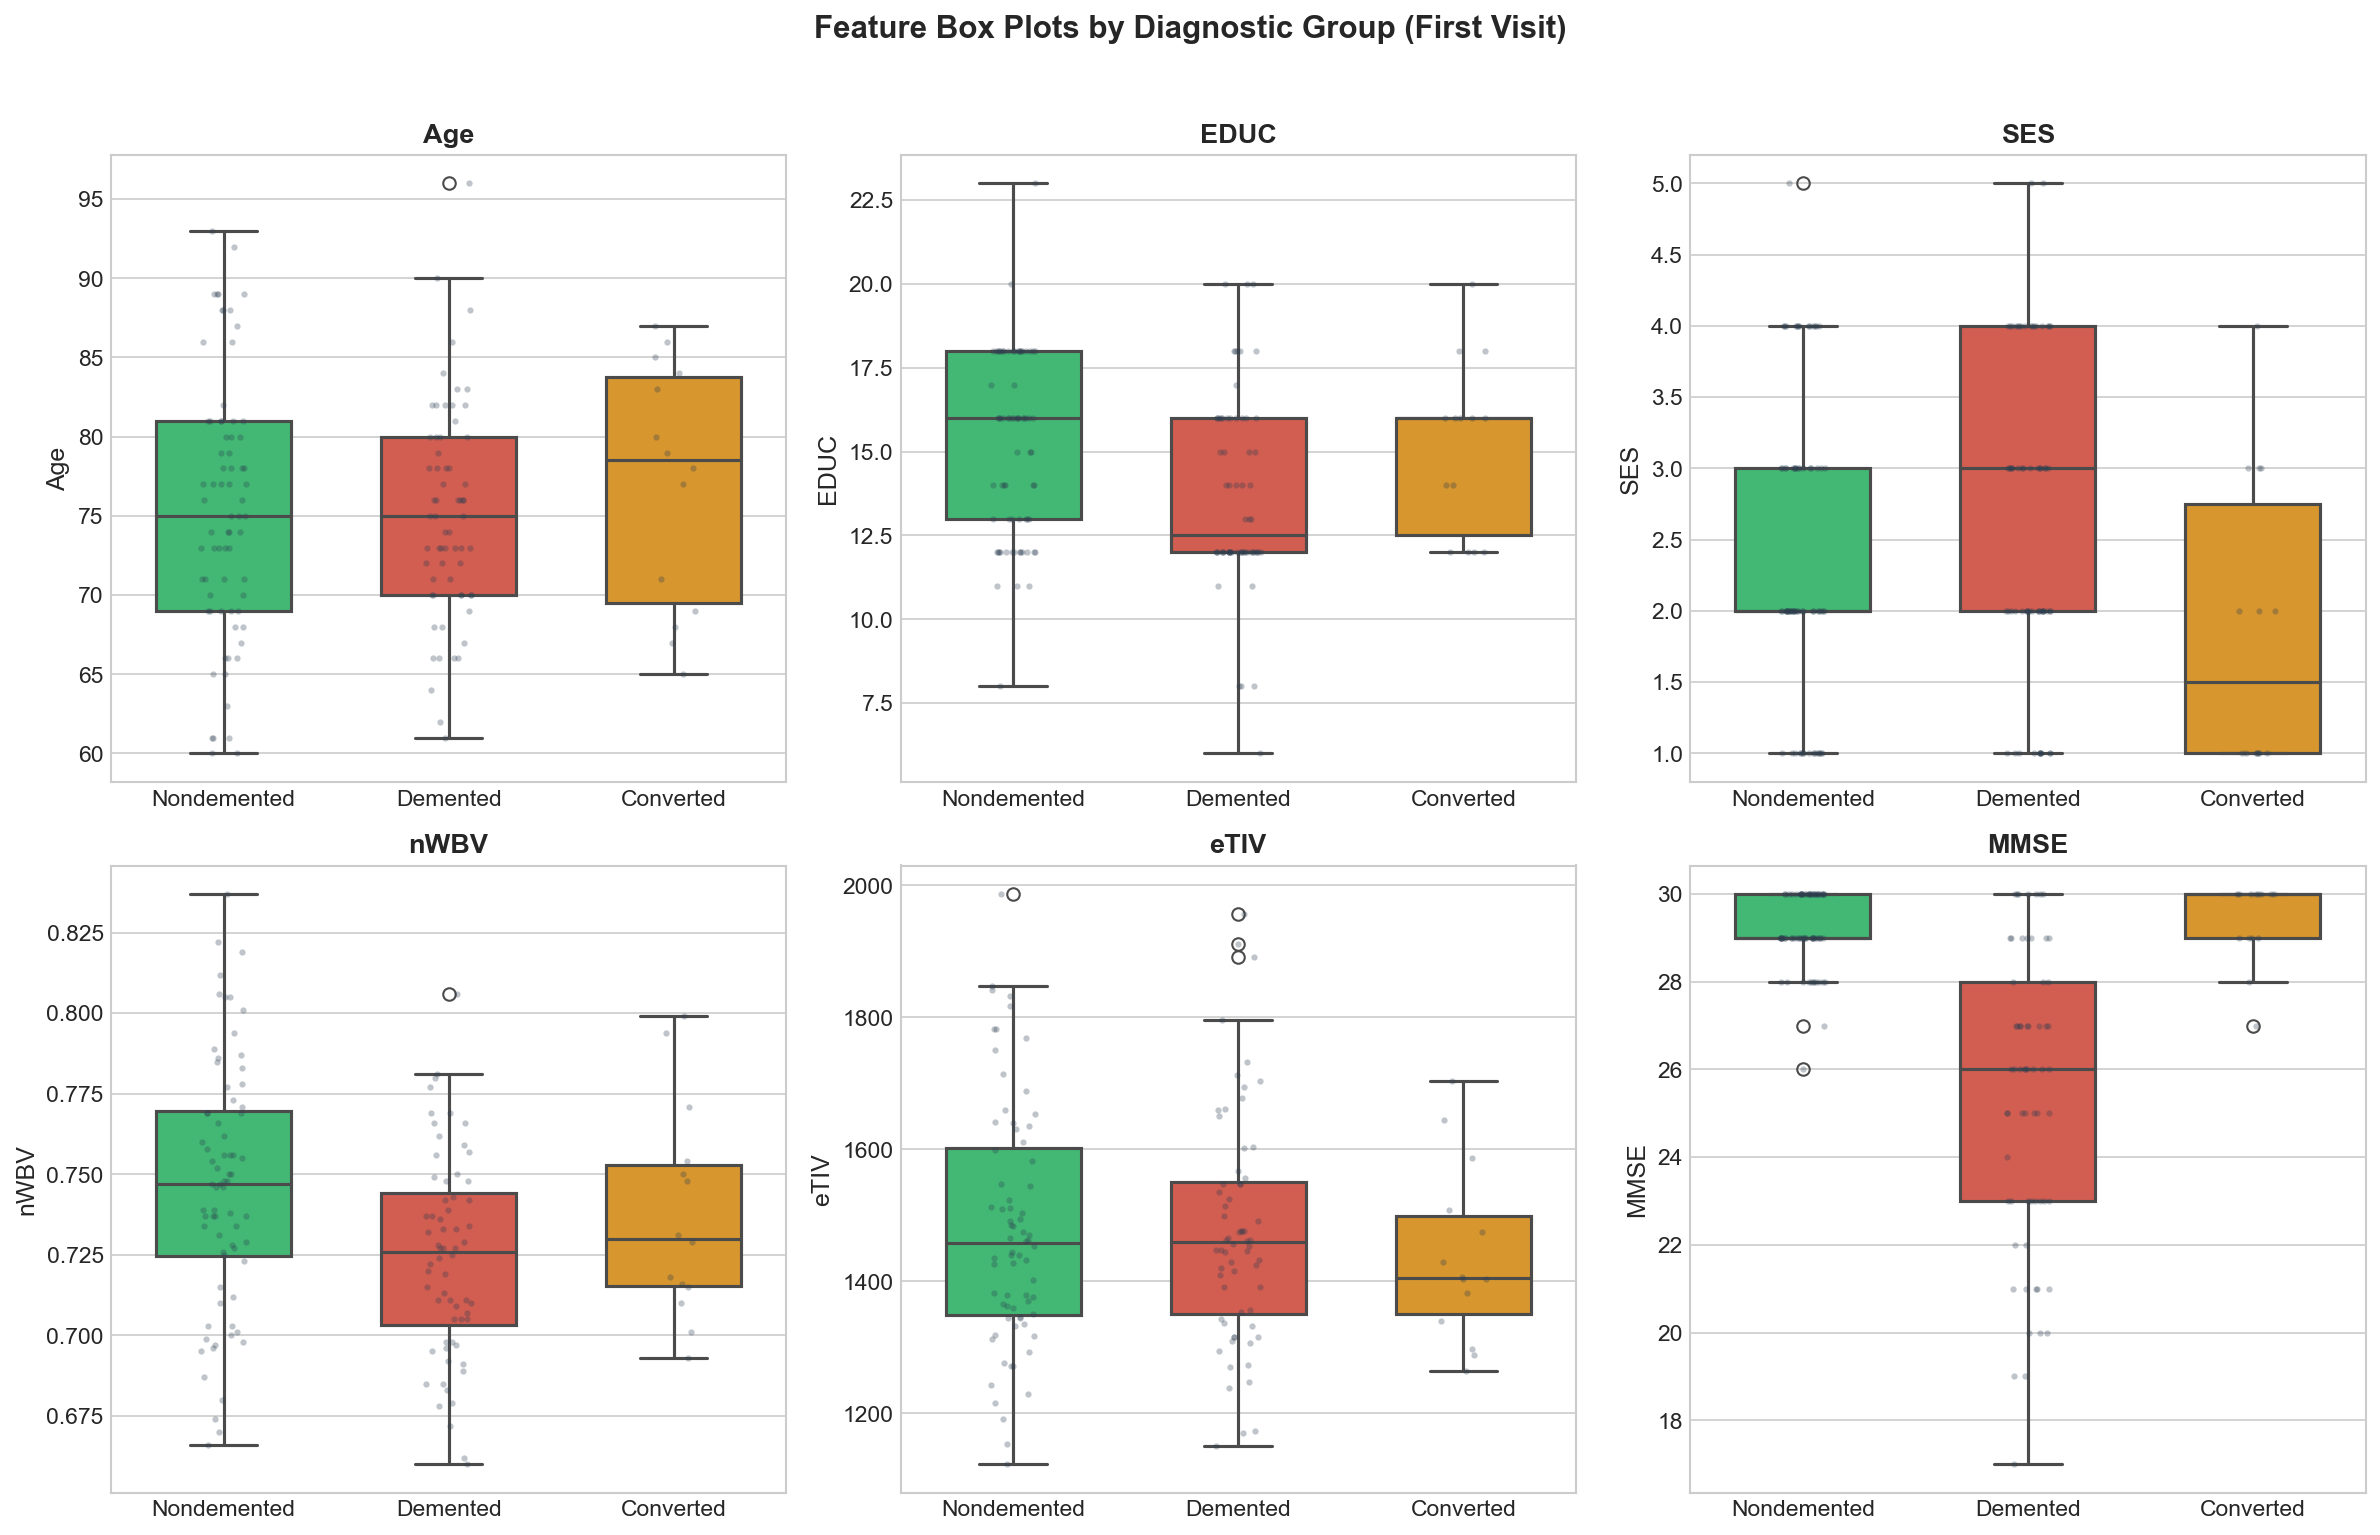

In [21]:
# Box plots for key features by group
box_features = ["Age", "EDUC", "SES", "nWBV", "eTIV", "MMSE"]
group_order = ["Nondemented", "Demented", "Converted"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(box_features):
    ax = axes[i]
    palette = {g: COLOR_PALETTE[g] for g in group_order}
    sns.boxplot(
        data=df_first,
        x="Group",
        y=feature,
        order=group_order,
        palette=palette,
        ax=ax,
        width=0.6,
        linewidth=1.5,
    )
    sns.stripplot(
        data=df_first,
        x="Group",
        y=feature,
        order=group_order,
        color="#2c3e50",
        alpha=0.3,
        size=3,
        ax=ax,
    )
    ax.set_title(feature, fontweight="bold", fontsize=13)
    ax.set_xlabel("")

fig.suptitle("Feature Box Plots by Diagnostic Group (First Visit)", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Feature distribution observations:**
- **Age**: Demented subjects tend to be slightly older; converters overlap with both groups
- **EDUC**: Somewhat lower education in the demented group
- **nWBV**: Clear separation -- demented subjects have lower brain volume (more atrophy)
- **eTIV**: Less differentiation between groups (total intracranial volume is largely anatomical)
- **MMSE**: Dramatic separation (but this is the circularity problem -- MMSE tracks CDR)
- **SES**: Slight differences but high overlap between groups

---
## 8. Correlation Matrix

We compute pairwise correlations between all numeric features to identify
redundancies and the MMSE-CDR relationship.

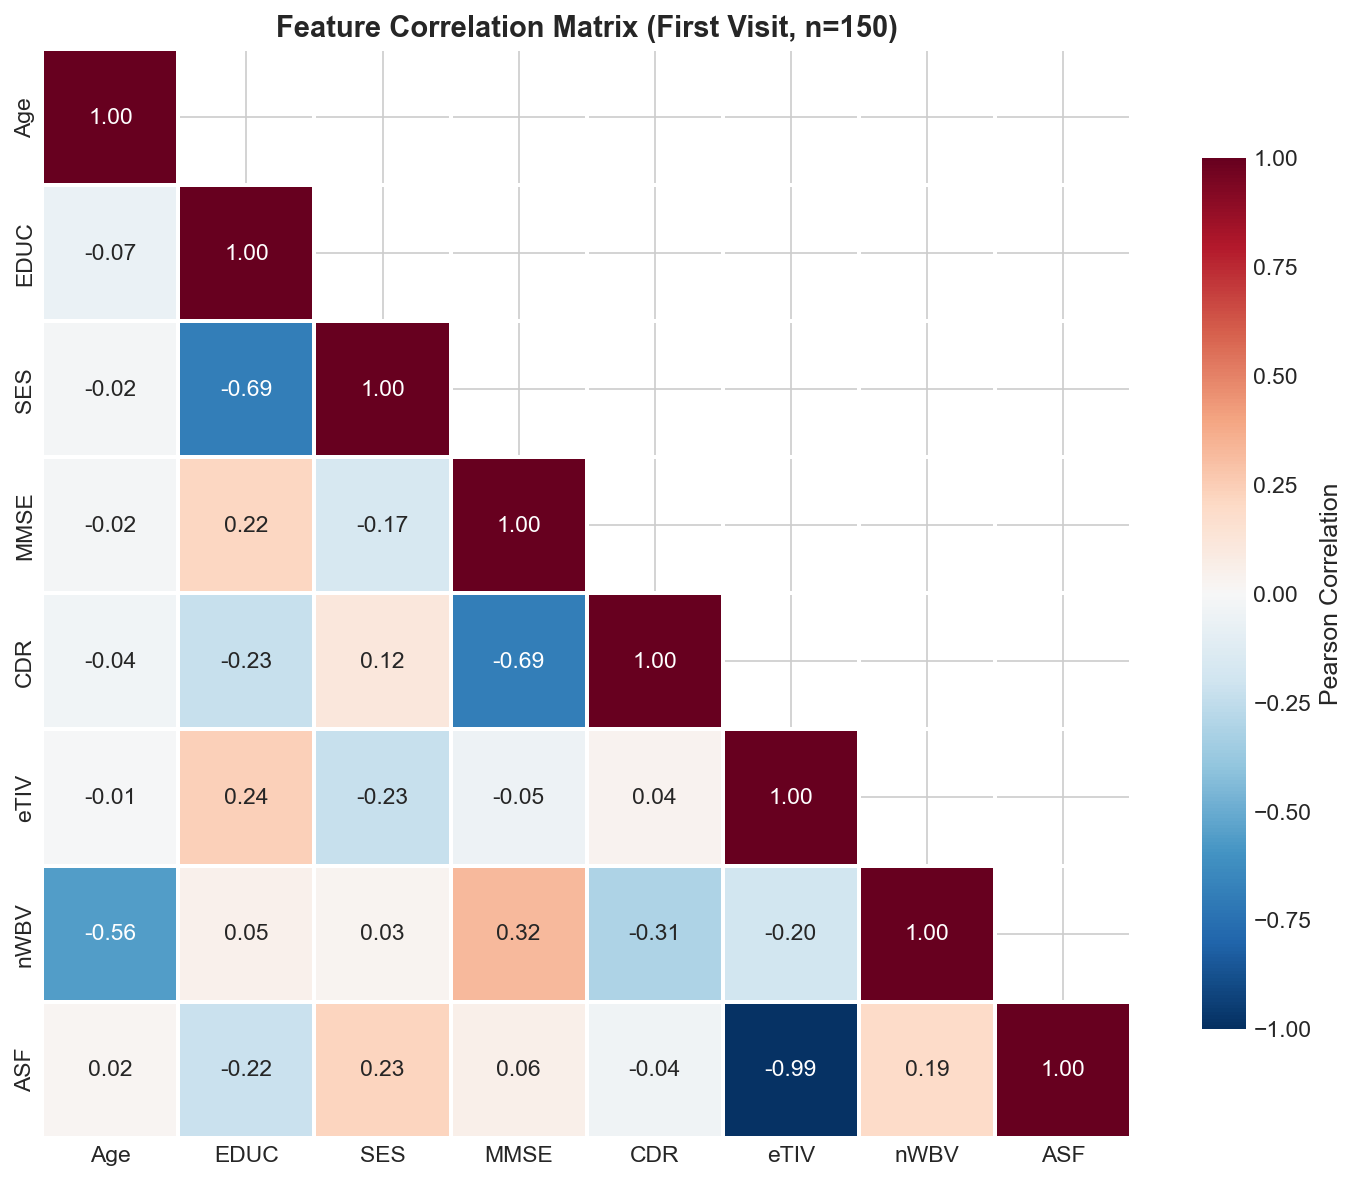


*** CRITICAL: MMSE-CDR correlation = -0.692 ***
This confirms the circularity: MMSE is nearly a direct proxy for the target label.

Other notable correlations:
  eTIV-ASF:  -0.988  (ASF is derived from eTIV)
  Age-nWBV:  -0.558  (brain atrophy increases with age)
  nWBV-CDR:  -0.311  (atrophy tracks with dementia)


In [22]:
# Correlation matrix
corr_cols = ["Age", "EDUC", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]
corr_matrix = df_first[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    ax=ax,
    cbar_kws={"label": "Pearson Correlation", "shrink": 0.8},
    annot_kws={"fontsize": 11},
)

ax.set_title("Feature Correlation Matrix (First Visit, n=150)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

# Highlight the MMSE-CDR correlation
mmse_cdr_corr = corr_matrix.loc["MMSE", "CDR"]
print(f"\n*** CRITICAL: MMSE-CDR correlation = {mmse_cdr_corr:.3f} ***")
print(f"This confirms the circularity: MMSE is nearly a direct proxy for the target label.")
print(f"\nOther notable correlations:")
print(f"  eTIV-ASF:  {corr_matrix.loc['eTIV', 'ASF']:.3f}  (ASF is derived from eTIV)")
print(f"  Age-nWBV:  {corr_matrix.loc['Age', 'nWBV']:.3f}  (brain atrophy increases with age)")
print(f"  nWBV-CDR:  {corr_matrix.loc['nWBV', 'CDR']:.3f}  (atrophy tracks with dementia)")

**Correlation insights:**
- **MMSE-CDR**: Strong negative correlation confirms the circularity problem
- **eTIV-ASF**: Nearly perfect negative correlation (ASF = Atlas Scaling Factor, derived from eTIV). These are redundant.
- **Age-nWBV**: Moderate negative correlation (older subjects have more brain atrophy)
- **nWBV-CDR**: Moderate negative correlation (lower brain volume associated with higher CDR)
- **EDUC-SES**: Moderate correlation (education and socioeconomic status are related)

---
## 9. Key Takeaways

### Dataset Summary
- **150 unique subjects**, 373 total visits (longitudinal design)
- **Three groups**: 72 Nondemented, 64 Demented, 14 Converted
- Groups are roughly balanced for binary classification (72 vs 78 when collapsing Converted into Demented)

### Critical Finding: MMSE-CDR Circularity
- CDR (Clinical Dementia Rating) **defines** the Group label
- MMSE is strongly correlated with CDR
- Using MMSE as a feature creates **information leakage** from the target into the features
- This inflates accuracy and gives a false sense of model performance
- **Our ablation study must compare models with and without MMSE**

### Converters
- Only **8 converter subjects** -- a small but clinically important subgroup
- They show progressive brain atrophy (declining nWBV) and cognitive decline (declining MMSE)
- At first visit, converters look similar to the Nondemented group

### Missing Data
- SES has minor missingness (~8 subjects across all visits)
- Median imputation is appropriate given the small number of missing values
- No other features have significant missingness

### Feature Insights
- **nWBV** (brain volume) shows the best group separation among non-circular features
- **eTIV** and **ASF** are redundant (ASF is derived from eTIV)
- **Age** shows moderate group separation
- **EDUC** and **SES** show subtle group differences

### Next Steps
1. Feature engineering (Notebook 02)
2. MMSE ablation study to quantify circularity inflation
3. Model comparison with proper cross-validation
4. Honest reporting of performance with and without MMSE